**ENERGY FORECASTING**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor


In [46]:
print("Number of rows in dataset:", len(df))

Number of rows in dataset: 17520


In [47]:
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[['consumption']])

In [48]:
n_rows = len(scaled_data)
n_steps = min(24, n_rows // 2) 
print("Using n_steps (window size):", n_steps)

Using n_steps (window size): 24


In [49]:
def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, n_steps)
print("Shape of X:", X.shape, "Shape of y:", y.shape)

Shape of X: (17496, 24, 1) Shape of y: (17496, 1)


In [50]:
X = X.reshape(X.shape[0], -1)


In [51]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [52]:
mlp = MLPRegressor(hidden_layer_sizes=(50, 25),
                   activation='relu',
                   solver='adam',
                   max_iter=500,
                   random_state=42)

mlp.fit(X_train, y_train.ravel())


MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)

In [53]:
y_pred = mlp.predict(X_test)


In [54]:
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1,1))

In [55]:
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

print("MLP Forecasting Results:")
print("MAE:", mae)
print("RMSE:", rmse)

MLP Forecasting Results:
MAE: 1.915449791597598
RMSE: 2.4247355387827447


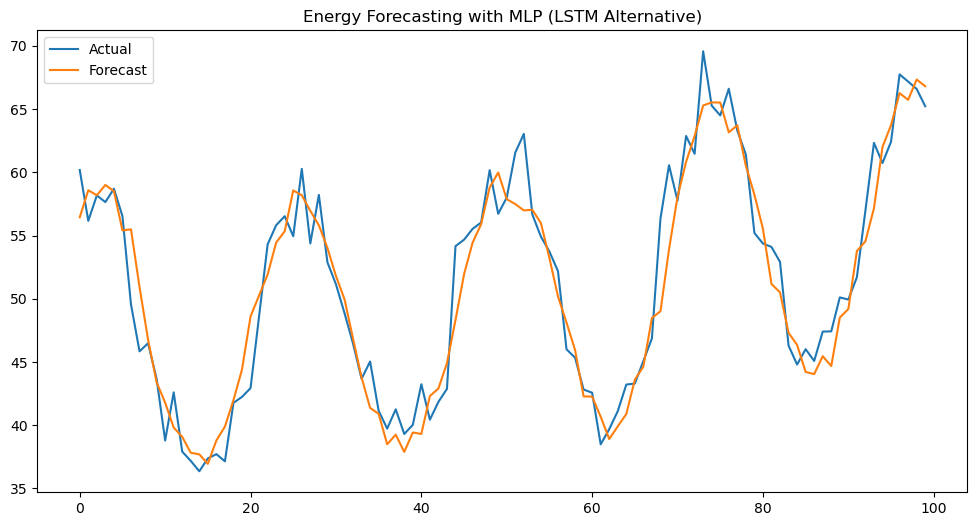

In [58]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:100], label="Actual")
plt.plot(y_pred_inv[:100], label="Forecast")
plt.legend()
plt.title("Energy Forecasting with MLP (LSTM Alternative)")
plt.show()